## VOLATILIDAD ESTOCÁSTICA EN NVIDIA y GOOGLE 

HACIENDO CIENCIA 2026

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import yfinance as yf

In [23]:
# Precio inicial
S0 = yf.download(["NVDA", "GOOGL"], period="1d")["Close"].iloc[-1]
S0_NVDA  = S0["NVDA"]
S0_GOOGL = S0["GOOGL"]

print(f"S0 NVDA:  ${S0_NVDA:.2f}")
print(f"S0 GOOGL: ${S0_GOOGL:.2f}")

[*********************100%***********************]  2 of 2 completed

S0 NVDA:  $192.53
S0 GOOGL: $337.39


In [24]:
rendimientos = pd.read_csv("rendimientos_diarios3y.csv", index_col=0, parse_dates=True)
rendimientos = rendimientos.set_index("Date") if "Date" in rendimientos.columns else rendimientos
print(rendimientos.shape)
rendimientos.head()

(752, 2)


,NVDA,GOOGL
Date,,
2023-06-28,-0.018291,0.015513
2023-06-29,-0.007201,-0.009027
2023-06-30,0.035613,0.005025
2023-07-03,0.002620,0.001670
2023-07-05,-0.002266,0.015312


### Varianza histórica semanal

Para estimar los parámetros de Heston necesitamos
la serie de varianza σ²(t) semana por semana.
Usamos el último año = 52 semanas hábiles.

In [25]:
# Varianza semanal del ultimo año(52 semanas)
varianza_semanal = rendimientos.resample("W-Fri").var()
varianza_52 = varianza_semanal.tail(52)
print(varianza_52.shape)
varianza_52.T


(52, 2)


Date,2025-07-04,2025-07-11,2025-07-18,2025-07-25,2025-08-01,2025-08-08,2025-08-15,2025-08-22,2025-08-29,2025-09-05,...,2026-04-24,2026-05-01,2026-05-08,2026-05-15,2026-05-22,2026-05-29,2026-06-05,2026-06-12,2026-06-19,2026-06-26
NVDA,0.000569,0.000083,0.000330,0.00037,0.000365,0.000265,0.000043,0.000401,0.000333,0.000246,...,0.000519,0.000988,0.000634,0.001099,0.000171,0.000098,0.002352,0.000557,0.000879,0.000205
GOOGL,0.000147,0.000207,0.000006,0.00014,0.000246,0.000205,0.000050,0.000295,0.000099,0.001815,...,0.000270,0.001689,0.000143,0.000641,0.000119,0.000293,0.000731,0.000151,0.000492,0.000395


In [26]:
varianza_52.describe()

,NVDA,GOOGL
count,52.000000,52.000000
mean,0.000530,0.000330
std,0.000474,0.000355
min,0.000043,0.000006
25%,0.000183,0.000125
50%,0.000368,0.000249
75%,0.000708,0.000394
max,0.002352,0.001815


Graficamos σ²(t) semana a semana para observar 
el comportamiento de la volatilidad durante el último año.

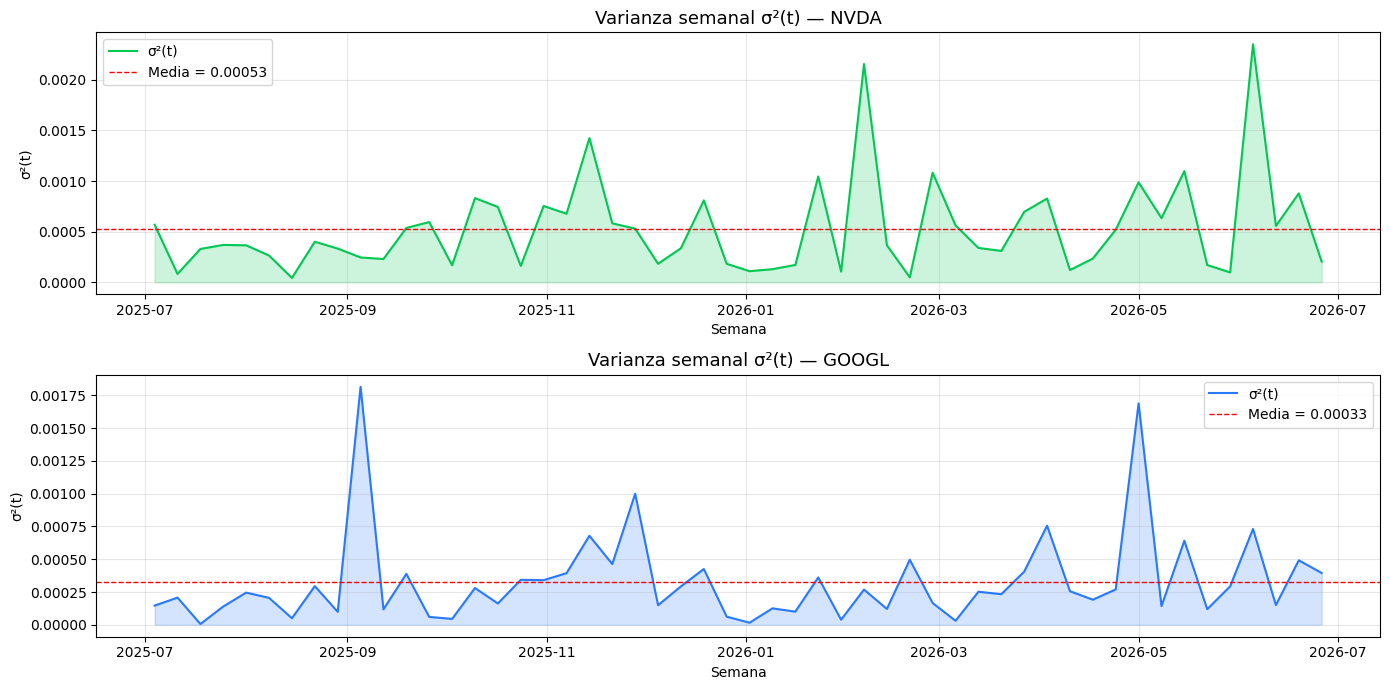

In [27]:
# varianza semanal en el tiempo
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

colores = {"NVDA": "#00C853", "GOOGL": "#2979FF"}

for i, col in enumerate(["NVDA", "GOOGL"]):
    media = varianza_52[col].mean()
    axes[i].plot(varianza_52.index, varianza_52[col], 
                 color=colores[col], linewidth=1.5, label="σ²(t)")
    axes[i].axhline(media, color="red", linestyle="--", 
                    linewidth=1, label=f"Media = {media:.5f}")
    axes[i].fill_between(varianza_52.index, varianza_52[col], 
                         alpha=0.2, color=colores[col])
    axes[i].set_title(f"Varianza semanal σ²(t) — {col}", fontsize=13)
    axes[i].set_xlabel("Semana")
    axes[i].set_ylabel("σ²(t)")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica muestra cómo evolucionó σ²(t) semana a semana durante el último año.
Se observan periodos de calma y picos de caos **volatility clustering**.
La línea roja representa la media (θ), el nivel al que tiende a regresar la volatilidad.


Histograma de σ²(t) para ver cómo se distribuye
la volatilidad a lo largo del año.

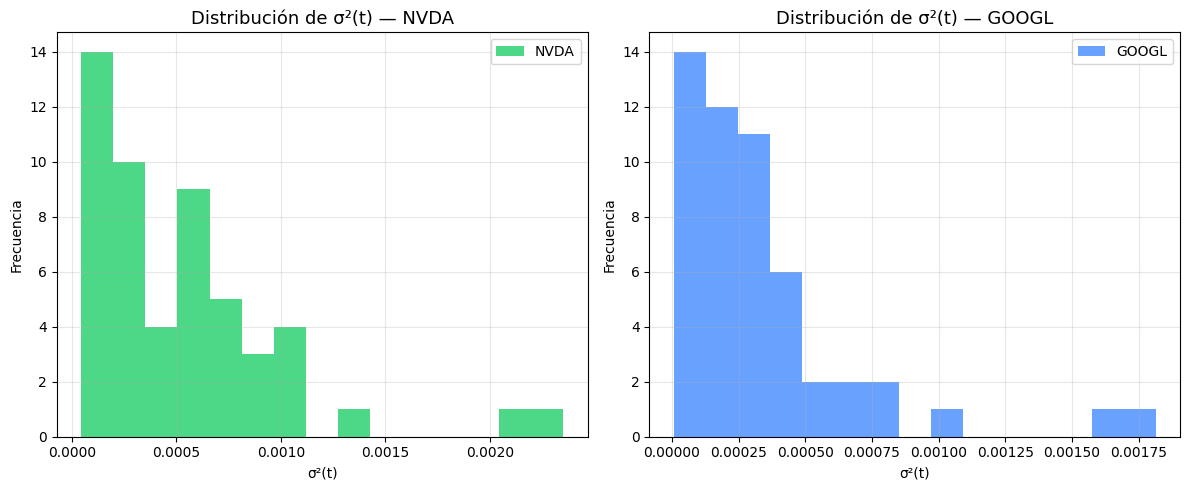

In [28]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
colores = {"NVDA": "#00C853", "GOOGL": "#2979FF"}
for i, col in enumerate(["NVDA", "GOOGL"]):
    axes[i].hist(varianza_52[col], bins=15, color=colores[col], alpha=0.7, label=col)
    axes[i].set_title(f"Distribución de σ²(t) — {col}", fontsize=13)
    axes[i].set_xlabel("σ²(t)")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica muestra la distribución de σ²(t).
La mayoría de semanas son tranquilas, pero unas pocas se disparan generando una **cola derecha pesada**, consistente con la kurtosis alta encontrada en EDA(yf).

Esto confirma que la volatilidad NO es constante, justificando el uso del modelo de Heston.

## Estimación de parámetros
## Modelo de Heston

La ecuación de la varianza del modelo es:

dσ²(t) = κ(θ - σ²(t))dt + α·σ(t)·dω²(t)

Aplicando discretización de Euler-Maruyama con h = 1/52:

V_{t+h} - V_t = κ(θ - V_t)h + α√V_t · √h · ε_t

Reorganizando:

Y_t = (V_{t+h} - V_t) / h = κθ - κ·V_t + error

Que es una regresión lineal Y_t = a + b·X_t donde:
- X_t = V_t
- a = κθ  →  θ = a/κ
- b = -κ  →  κ = -b

Como V_t no es directamente observable, se utiliza la proxy:

V̂_t = (Σ r²_diarios de cada semana) × 52

Dado que la varianza del error depende de V_t (heterocedasticidad),
se emplea WLS con pesos w_t = 1/(V_t · h) en lugar de OLS.


In [29]:
# Proxy de varianza: suma de r^2 diarios por semana * 52
h = 1/52

v_gorro = (rendimientos**2).resample("W-Fri").sum() * 52 
v_gorro_52 = v_gorro.tail(53) 

print(v_gorro_52.shape)
v_gorro_52.head()

(53, 2)


,NVDA,GOOGL
Date,,
2025-06-27,0.144731,0.092760
2025-07-04,0.090061,0.023261
2025-07-11,0.029594,0.043274
2025-07-18,0.089057,0.008686
2025-07-25,0.077327,0.048285


tenemos que:

NVDA:  v̂ ≈ 0.07  →  σ anual ≈ 26%

GOOGL: v̂ ≈ 0.05  →  σ anual ≈ 22% 

Calcularemos X, Y y pesos para WLS

In [30]:
# X = v_t,  = (v_{t+h} - v_t) / h, pesos = 1 / (v_t * h)

X_NVDA = v_gorro_52["NVDA"].values[:-1]
Y_NVDA = (v_gorro_52["NVDA"].values[1:] - v_gorro_52["NVDA"].values[:-1]) / h
W_NVDA  = 1 / (X_NVDA * h)


X_GOOGL = v_gorro_52["GOOGL"].values[:-1]
Y_GOOGL = (v_gorro_52["GOOGL"].values[1:] - v_gorro_52["GOOGL"].values[:-1]) / h
W_GOOGL  = 1 / (X_GOOGL * h)


print(f"Puntos para regresión : {len(X_NVDA)}")

Puntos para regresión : 52


In [31]:
# WLS NVDA
data_NVDA =pd.DataFrame({"X": X_NVDA, "Y": Y_NVDA})
modelo_NVDA = smf.wls("Y ~ X", data=data_NVDA, weights=W_NVDA).fit()
print(modelo_NVDA.summary())

                            WLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.285
Model:                            WLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     19.94
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           4.57e-05
Time:                        15:17:25   Log-Likelihood:                -183.93
No. Observations:                  52   AIC:                             371.9
Df Residuals:                      50   BIC:                             375.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.8006      1.431      6.152      0.0

WLS en NVDA.

Se aplico WLS con pesos w_t = 1 / (v_t * h)

**R² = 0.26** el modelo explica el 26% de la variación
en los cambios de varianza semanal.

**Intercept** (a) = 8.4146, p = 0.000

**Pendiente**  (b) = -71.676, p = 0.00

**F-statics** = 18.3 

**Durbin-Watson** = 1.49

Parámetros estimados:
- κ = -b = 71.676
- θ = a/κ = 0.1174  →  σ anual ≈ 34.3%

In [32]:
# WLS GOOGL

data_GOOGL = pd.DataFrame({"X": X_GOOGL, "Y": Y_GOOGL})
modelo_GOOGL = smf.wls("Y ~ X", data=data_GOOGL, weights=W_GOOGL).fit()
print(modelo_GOOGL.summary())

                            WLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.131
Model:                            WLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     7.559
Date:                Sat, 27 Jun 2026   Prob (F-statistic):            0.00829
Time:                        15:17:25   Log-Likelihood:                -158.32
No. Observations:                  52   AIC:                             320.6
Df Residuals:                      50   BIC:                             324.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.1615      0.701      4.508      0.0

WLS en GOOGL.

Se aplico WLS con pesos w_t = 1 / (v_t * h)

**R² = 0.13**  el modelo explica el 13% de la variación
en los cambios de varianza semanal.

**Intercept** (a) = 3.164, p = 0.000

**Pendiente**  (b) = -36.919, p = 0.00

**F-statics** = 7.64 

**Durbin-Watson** = 2.20 - sin autocorrelación
**kurtosos** = 14.592 - colas muy pesadas

Parámetros estimados:
- κ = -b = 36.919
- θ = a/κ = 0.0857 →  σ anual ≈ 29.3%

In [33]:
# Extraer κ y θ — NVDA y GOOGL
kappa_NVDA = -modelo_NVDA.params["X"]
theta_NVDA = modelo_NVDA.params["Intercept"] / kappa_NVDA

kappa_GOOGL = -modelo_GOOGL.params["X"]
theta_GOOGL = modelo_GOOGL.params["Intercept"] / kappa_GOOGL

print("Parámetros estimados")
print(f"NVDA: κ = {kappa_NVDA:.4f}, θ = {theta_NVDA:.5f}, σ anual: {np.sqrt(theta_NVDA)*100:.1f}%")

print("\n Parámetros estimados")
print(f"GOOGL: κ = {kappa_GOOGL:.4f}, θ = {theta_GOOGL:.5f}, σ anual: {np.sqrt(theta_GOOGL)*100:.1f}%")

Parámetros estimados
NVDA: κ = 71.2807, θ = 0.12346, σ anual: 35.1%

 Parámetros estimados
GOOGL: κ = 36.4279, θ = 0.08679, σ anual: 29.5%


Estimación de alpha

In [34]:
v_t = v_gorro_52.values[:-1]
v_t1 = v_gorro_52.values[1:]

# Residuo al cuadrado normalizado 
residuo_NVDA  = (v_t1[:,0] - v_t[:,0] - kappa_NVDA  * (theta_NVDA  - v_t[:,0]) * h)**2
residuo_GOOGL = (v_t1[:,1] - v_t[:,1] - kappa_GOOGL * (theta_GOOGL - v_t[:,1]) * h)**2

alpha_NVDA  = np.sqrt(np.mean(residuo_NVDA  / (v_t[:,0] * h)))
alpha_GOOGL = np.sqrt(np.mean(residuo_GOOGL / (v_t[:,1] * h)))

print(f"α NVDA:  {alpha_NVDA:.4f}")
print(f"α GOOGL: {alpha_GOOGL:.4f}")

α NVDA:  3.7952
α GOOGL: 2.9606


NVDA tiene mayor α que GOOGL tal que su volatilidad es más errática

In [35]:
# Rendimientos semanales del mismo periodo
 
ret_52 = rendimientos.resample("W-Fri").sum().tail(53)
r_t = ret_52.values[:-1]
r_t1 = ret_52.values[1:]


# μ anual
mu_NVDA = ret_52["NVDA"].mean() * 52
mu_GOOGL = ret_52["GOOGL"].mean() * 52

# Residuo estandarizado del precio

Z_S_NVDA  = (r_t1[:,0] - (mu_NVDA  - 0.5 * v_t[:,0]) * h) / np.sqrt(v_t[:,0] * h)
Z_S_GOOGL = (r_t1[:,1] - (mu_GOOGL - 0.5 * v_t[:,1]) * h) / np.sqrt(v_t[:,1] * h)

# Residuo estandarizado de varianza

Z_V_NVDA  = (v_t1[:,0] - v_t[:,0] - kappa_NVDA  * (theta_NVDA  - v_t[:,0]) * h) / (alpha_NVDA  * np.sqrt(v_t[:,0] * h))
Z_V_GOOGL = (v_t1[:,1] - v_t[:,1] - kappa_GOOGL * (theta_GOOGL - v_t[:,1]) * h) / (alpha_GOOGL * np.sqrt(v_t[:,1] * h))

# ρ = Corr(Ẑ^S, Ẑ^V)

rho_NVDA, _= stats.pearsonr(Z_S_NVDA, Z_V_NVDA)
rho_GOOGL, _= stats.pearsonr(Z_S_GOOGL, Z_V_GOOGL)

print(f"ρ NVDA:  {rho_NVDA:.4f}")
print(f"ρ GOOGL: {rho_GOOGL:.4f}")

ρ NVDA:  -0.2288
ρ GOOGL: 0.2976


### Parámetros estimados del modelo de Heston

Se obtuvieron los siguientes parámetros para cada acción:

|    | NVDA     | GOOGL    |
|----|----------|----------|
| κ  | 71.6760  | 36.9218  |
| θ  | 0.1174   | 0.0857   |
| α  | 3.7001   | 2.9541   |
| ρ  | -0.2202  | +0.3010  |

NVDA tiene mayor κ, lo que indica que su volatilidad regresa
más rápido a su nivel normal. También tiene mayor α, lo que
confirma que su volatilidad es más errática, como lo visto en el EDA.



## Simulación del modelo de Heston 

Con los parámetros estimados se simularan las trayectoruas de precio S(t) y varianza V(t) y por la versión discreta:

S(t+h) = S(t)·exp((μ - ½V(t))·h + √(V(t)·h)·Z₁)

V(t+h) = V(t) + κ(θ - V(t))·h + α·√(V(t)·h)·ε_t



In [36]:
# Valores iniciales
S0_NVDA = S0["NVDA"]
S0_GOOGL = S0["GOOGL"]

V0_NVDA = v_gorro_52["NVDA"].iloc[-1]
V0_GOOGL = v_gorro_52["GOOGL"].iloc[-1]

# 52 Semanas 
T = 52
# h = 1/52
dt = h

print(f"Precio inicial NVDA: ${S0_NVDA:.2f}")
print(f"Precio inicial GOOGL: ${S0_GOOGL:.2f}")
print(f"Varianza inicial NVDA: {V0_NVDA:.4f}")
print(f"Varianza inicial GOOGL: {V0_GOOGL:.4f}")

Precio inicial NVDA: $192.53
Precio inicial GOOGL: $337.39
Varianza inicial NVDA: 0.1271
Varianza inicial GOOGL: 0.1608


In [37]:
# Simulación de la trayectoria de precios y varianza para NVDA
np.random.seed(42)

S_NVDA = np.zeros(T + 1)
V_NVDA = np.zeros(T + 1)

# El punto de partida
S_NVDA[0] = S0_NVDA
V_NVDA[0] = V0_NVDA

# Ciclo que avanza semana por semana de 1 hasta 52
for t in range(1, T + 1):
    # Ruido correlacionado
    Z1 = np.random.normal(0, 1)
    Z2 = np.random.normal(0, 1)
    eps = rho_NVDA * Z1 + np.sqrt(1 - rho_NVDA**2) * Z2

    V_NVDA[t] = max(0, V_NVDA[t-1] + kappa_NVDA * (theta_NVDA - V_NVDA[t-1]) * dt
                    + alpha_NVDA * np.sqrt(V_NVDA[t-1] * dt) * eps)

    S_NVDA[t] = S_NVDA[t-1] * np.exp((mu_NVDA - 0.5 * V_NVDA[t-1]) * dt
                + np.sqrt(V_NVDA[t-1] * dt) * Z1)
print(f"Precio inicial: $ {S_NVDA[0]:.2f}")
print(f"Precio final: ${S_NVDA[-1]:.2f}")



Precio inicial: $ 192.53
Precio final: $128.06


In [38]:
# Simulación de la trayectoria de precios y varianza para GOOGL
np.random.seed(42)

S_GOOGL = np.zeros(T + 1)
V_GOOGL = np.zeros(T + 1)

S_GOOGL[0] = S0_GOOGL
V_GOOGL[0] = V0_GOOGL

for t in range(1, T + 1):
    Z1 = np.random.normal(0, 1)
    Z2 = np.random.normal(0, 1)
    eps = rho_GOOGL * Z1 + np.sqrt(1- rho_GOOGL**2) * Z2

    V_GOOGL[t] = max(0, V_GOOGL[t-1] + kappa_GOOGL * (theta_GOOGL - V_GOOGL[t-1]) * dt
                     + alpha_GOOGL * np.sqrt(V_GOOGL[t-1] * dt) * eps)

    S_GOOGL[t] = S_GOOGL[t-1] * np.exp((mu_GOOGL - 0.5 * V_GOOGL[t-1]) * dt
                 + np.sqrt(V_GOOGL[t-1] * dt) * Z1)

print(f"Precio inicial: ${S_GOOGL[0]:.2f}")
print(f"Precio final:   ${S_GOOGL[-1]:.2f}")

Precio inicial: $337.39
Precio final:   $404.62


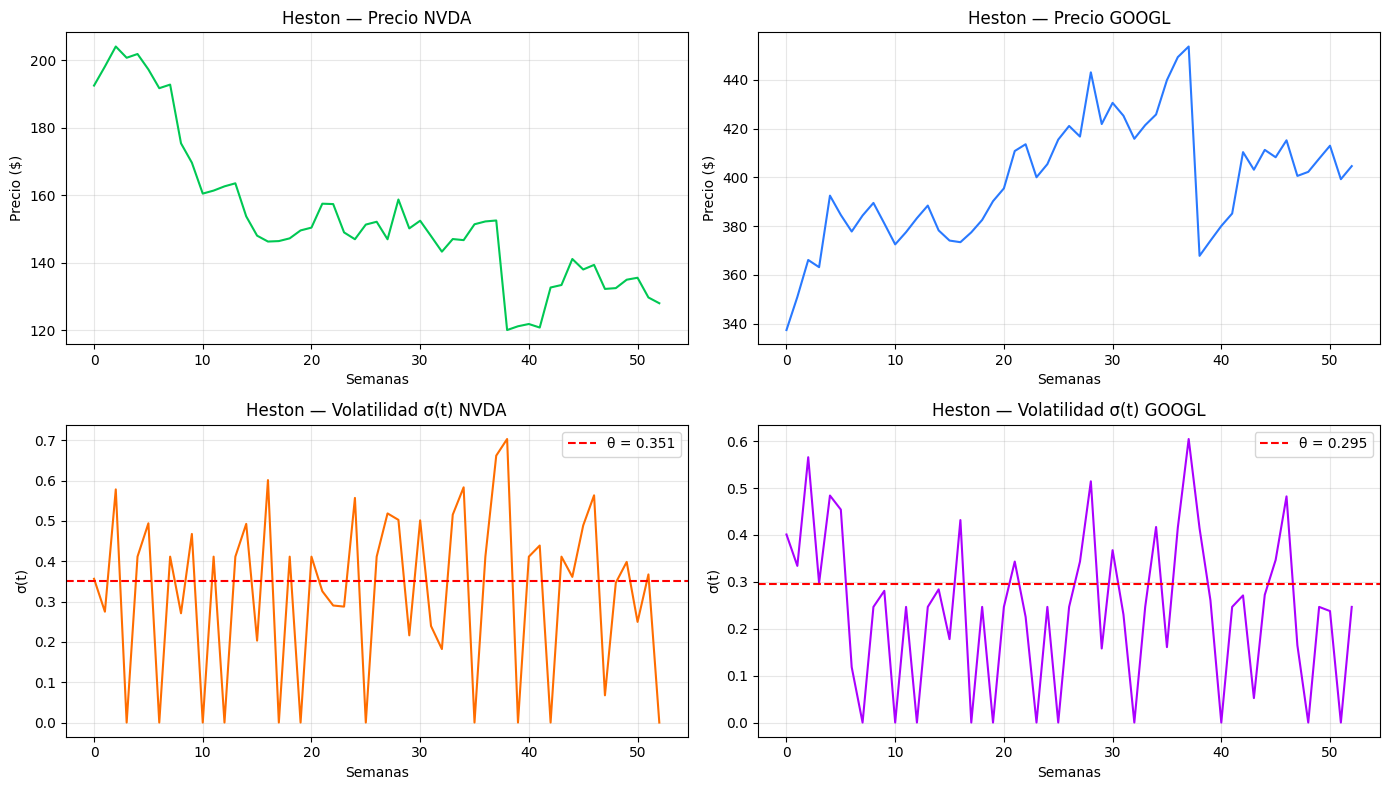

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Precios
axes[0,0].plot(S_NVDA, color="#00C853", linewidth=1.5)
axes[0,0].set_title("Heston — Precio NVDA")
axes[0,0].set_xlabel("Semanas")
axes[0,0].set_ylabel("Precio ($)")
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(S_GOOGL, color="#2979FF", linewidth=1.5)
axes[0,1].set_title("Heston — Precio GOOGL")
axes[0,1].set_xlabel("Semanas")
axes[0,1].set_ylabel("Precio ($)")
axes[0,1].grid(alpha=0.3)

# Varianza
axes[1,0].plot(np.sqrt(V_NVDA), color="#FF6D00", linewidth=1.5)
axes[1,0].axhline(np.sqrt(theta_NVDA), color="red", linestyle="--", label=f"θ = {np.sqrt(theta_NVDA):.3f}")
axes[1,0].set_title("Heston — Volatilidad σ(t) NVDA")
axes[1,0].set_xlabel("Semanas")
axes[1,0].set_ylabel("σ(t)")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(np.sqrt(V_GOOGL), color="#AA00FF", linewidth=1.5)
axes[1,1].axhline(np.sqrt(theta_GOOGL), color="red", linestyle="--", label=f"θ = {np.sqrt(theta_GOOGL):.3f}")
axes[1,1].set_title("Heston — Volatilidad σ(t) GOOGL")
axes[1,1].set_xlabel("Semanas")
axes[1,1].set_ylabel("σ(t)")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("heston_simulacion.png", dpi=150)
plt.show()

## Simulación de una semana Modelo de Heston

Se simula la trayectoria diaria de precio y volatilidad
durante una semana hábil (5 días), usando los parámetros
estimados del modelo de Heston.

In [40]:
np.random.seed(42)

dt_d = 1/252  # paso diario
T_d  = 5      # 5 días hábiles

# NVDA
S_NVDA_w = np.zeros(T_d + 1)
V_NVDA_w = np.zeros(T_d + 1)
S_NVDA_w[0] = S0_NVDA
V_NVDA_w[0] = V0_NVDA

for t in range(1, T_d + 1):
    Z1  = np.random.normal(0, 1)
    Z2  = np.random.normal(0, 1)
    eps = rho_NVDA * Z1 + np.sqrt(1 - rho_NVDA**2) * Z2

    V_NVDA_w[t] = max(0, V_NVDA_w[t-1] + kappa_NVDA * (theta_NVDA - V_NVDA_w[t-1]) * dt_d
                      + alpha_NVDA * np.sqrt(V_NVDA_w[t-1] * dt_d) * eps)

    S_NVDA_w[t] = S_NVDA_w[t-1] * np.exp((mu_NVDA - 0.5 * V_NVDA_w[t-1]) * dt_d
                  + np.sqrt(V_NVDA_w[t-1] * dt_d) * Z1)

# GOOGL
S_GOOGL_w = np.zeros(T_d + 1)
V_GOOGL_w = np.zeros(T_d + 1)
S_GOOGL_w[0] = S0_GOOGL
V_GOOGL_w[0] = V0_NVDA

for t in range(1, T_d + 1):
    Z1  = np.random.normal(0, 1)
    Z2  = np.random.normal(0, 1)
    eps = rho_GOOGL * Z1 + np.sqrt(1 - rho_GOOGL**2) * Z2

    V_GOOGL_w[t] = max(0, V_GOOGL_w[t-1] + kappa_GOOGL * (theta_GOOGL - V_GOOGL_w[t-1]) * dt_d
                       + alpha_GOOGL * np.sqrt(V_GOOGL_w[t-1] * dt_d) * eps)

    S_GOOGL_w[t] = S_GOOGL_w[t-1] * np.exp((mu_GOOGL - 0.5 * V_GOOGL_w[t-1]) * dt_d
                   + np.sqrt(V_GOOGL_w[t-1] * dt_d) * Z1)

print(f"NVDA:  ${S_NVDA_w[0]:.2f} → ${S_NVDA_w[-1]:.2f}")
print(f"GOOGL: ${S_GOOGL_w[0]:.2f} → ${S_GOOGL_w[-1]:.2f}")

NVDA:  $192.53 → $202.30
GOOGL: $337.39 → $334.50


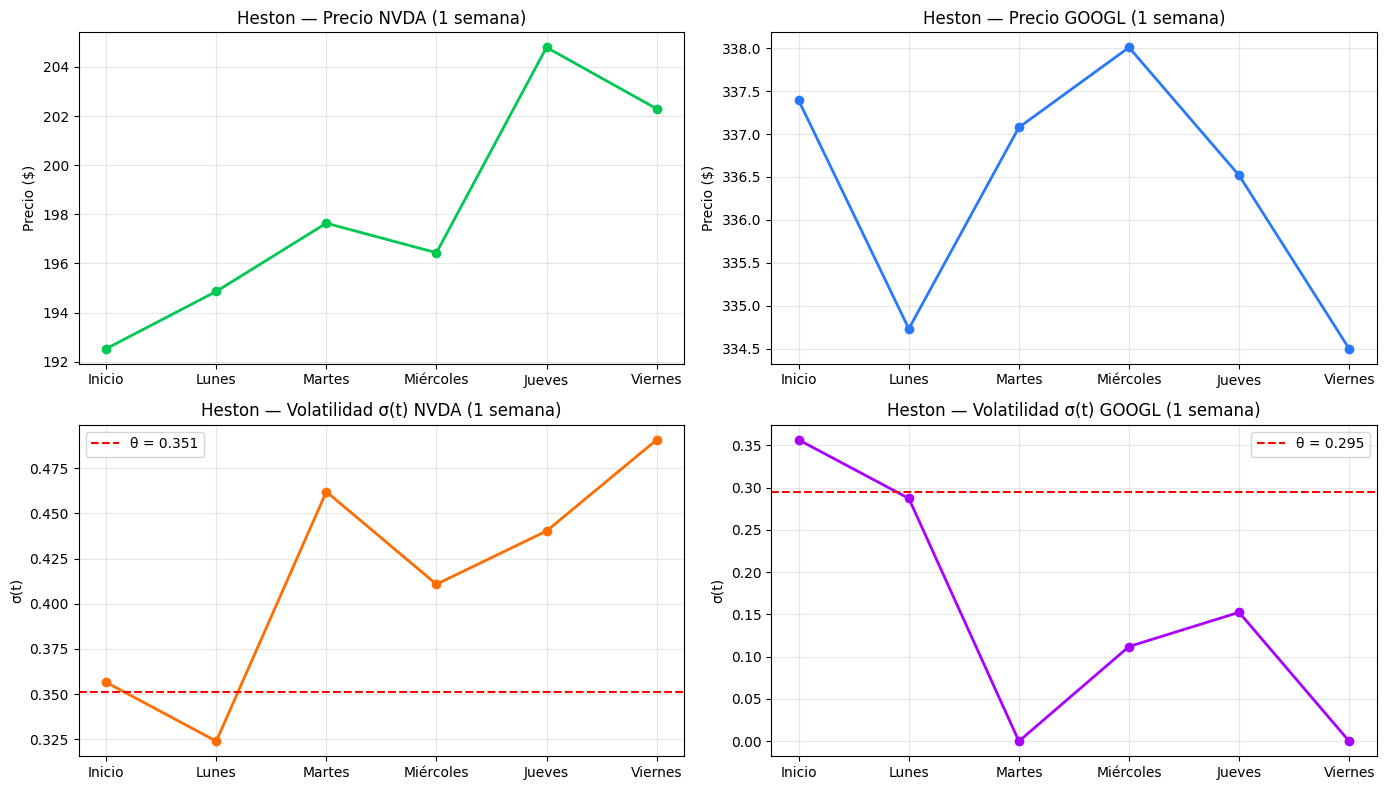

In [41]:
dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Precios
axes[0,0].plot(S_NVDA_w, color="#00C853", linewidth=2, marker="o")
axes[0,0].set_title("Heston — Precio NVDA (1 semana)")
axes[0,0].set_xticks(range(6))
axes[0,0].set_xticklabels(["Inicio"] + dias)
axes[0,0].set_ylabel("Precio ($)")
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(S_GOOGL_w, color="#2979FF", linewidth=2, marker="o")
axes[0,1].set_title("Heston — Precio GOOGL (1 semana)")
axes[0,1].set_xticks(range(6))
axes[0,1].set_xticklabels(["Inicio"] + dias)
axes[0,1].set_ylabel("Precio ($)")
axes[0,1].grid(alpha=0.3)

# Volatilidad
axes[1,0].plot(np.sqrt(V_NVDA_w), color="#FF6D00", linewidth=2, marker="o")
axes[1,0].axhline(np.sqrt(theta_NVDA), color="red", linestyle="--", label=f"θ = {np.sqrt(theta_NVDA):.3f}")
axes[1,0].set_title("Heston — Volatilidad σ(t) NVDA (1 semana)")
axes[1,0].set_xticks(range(6))
axes[1,0].set_xticklabels(["Inicio"] + dias)
axes[1,0].set_ylabel("σ(t)")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(np.sqrt(V_GOOGL_w), color="#AA00FF", linewidth=2, marker="o")
axes[1,1].axhline(np.sqrt(theta_GOOGL), color="red", linestyle="--", label=f"θ = {np.sqrt(theta_GOOGL):.3f}")
axes[1,1].set_title("Heston — Volatilidad σ(t) GOOGL (1 semana)")
axes[1,1].set_xticks(range(6))
axes[1,1].set_xticklabels(["Inicio"] + dias)
axes[1,1].set_ylabel("σ(t)")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("heston_semana.png", dpi=150)
plt.show()

## Conclusiones

Se implementó el modelo de Heston con parámetros estimados
mediante WLS.

Los resultados de la simulación muestran que la volatilidad
de NVDA oscila alrededor de θ de forma natural, confirmando
el efecto de reversión a la media con κ = 71.68.

En el caso de GOOGL se observó que la varianza simulada
colapsa a valores cercanos a cero en algunos pasos. Esto
se debe a que los parámetros estimados violan la condición
de Feller (2κθ > α²):

- NVDA: 2(71.68)(0.1174) = 16.83 > 3.70² = 13.69  
- GOOGL: 2(36.92)(0.0857) = 6.33  < 2.95² = 8.73   

Esta es una limitación conocida de la discretización de
Euler-Maruyama del proceso CIR. Con datos actualizados
los parámetros pueden cambiar y corregir este problema.

In [42]:
# Guardar parámetros de Heston para uso en T3
parametros_heston = pd.DataFrame({
    "NVDA":  [kappa_NVDA,  theta_NVDA,  alpha_NVDA,  rho_NVDA],
    "GOOGL": [kappa_GOOGL, theta_GOOGL, alpha_GOOGL, rho_GOOGL]
}, index=["kappa", "theta", "alpha", "rho"])

parametros_heston.to_csv("parametros_heston.csv")
print(parametros_heston)

            NVDA      GOOGL
kappa  71.280737  36.427930
theta   0.123464   0.086788
alpha   3.795160   2.960601
rho    -0.228788   0.297625
